# SpaceX S-1 — The debt picture: \$30B of borrowings, a \$20B bullet, and an IPO with a job to do

Sibling to the Space / Connectivity / AI notebooks. Those ask *can the businesses make money?*
This one asks the question that comes due first: **can SpaceX pay its lenders and stay solvent
while it keeps spending \$20B+ a year on Starship and AI compute?**

The headline from the S-1 is deceptively calm. As of **March 31, 2026** SpaceX carries
**\$30.3B of debt and finance leases**, against **\$23.7B of cash and marketable securities** — a
manageable-looking **\$6.6B net debt** for a company doing **\$18.7B of revenue** and **\$6.6B of
Adjusted EBITDA**. But two facts turn that calm into a countdown:

1. **\$20B of it is a single bridge loan that matures in September 2027** (extendable to March 2028) —
   a *bullet*, i.e. no amortization, the whole principal lands at once. It is explicitly designed to
   be repaid out of **IPO proceeds within six months** of the offering.
2. SpaceX **burns ~\$14B of free cash a year** (operating cash minus capex). The debt isn't being
   retired by the business; it's being *rolled and topped up* by capital markets.

So the debt picture is really a **funding picture**, and the funding picture is the whole reason
this S-1 exists.

**Roadmap.**
1. **Liquidity** — cash + marketable securities vs gross debt; what "net debt" actually is.
2. **The debt stack today** — every instrument outstanding at Mar 31 2026, its rate and maturity.
3. **The March 2026 refinancing** — how five high-rate subsidiary loans became one cheap \$20B bridge,
   and the \$1,526M loss that came with it.
4. **The cash cost of debt** — effective interest rates, what they actually pay, and rate sensitivity.
5. **The maturity wall** — when principal comes due, before and after the refinancing.
6. **Net debt & the leverage covenant** — the one financial maintenance test, and how much headroom.
7. **Solvency & the raise** — how much the IPO (and future offerings) must bring in, the dilution that
   implies, and why free cash flow from Connectivity is the only thing that ends the cycle.

> **Finance terms, plain English (we assume you know the tech, not the treasury desk).**
> *Principal* = the amount borrowed that must be repaid. *Coupon / stated rate* = the contractual
> interest rate. *Effective interest rate* = the true annual cost once fees and discounts are
> amortized in — always the number to trust. *Secured* = backed by specific collateral (lenders get
> those assets first in a default); *unsecured* = backed only by the company's promise. *Bullet
> maturity* = entire principal due on one date, no installments. *Net debt* = gross debt minus cash &
> liquid securities — what you'd still owe if you swept the bank account. *Covenant* = a promise to
> lenders; a *maintenance covenant* must hold every quarter or the loan can be called. *Free cash
> flow (FCF)* = operating cash flow minus capital expenditures — the cash actually left over after
> keeping the lights on and building the factories. *Run rate* = a current
> figure projected forward as a steady annual pace ("what's the yearly number if today's terms just
> persist?") — the right lens precisely when a one-time event like a refinancing makes the *reported*
> trailing numbers a poor guide to the *go-forward* ones. *EBITDA* = earnings before interest, taxes,
> depreciation & amortization; *Adjusted EBITDA* further adds back stock-based comp and one-offs —
> treat both with suspicion for SpaceX (see §6).


In [1]:
# Locate the repo root (the directory containing `analysis/`) so imports work from anywhere.
import os, sys
_p = os.getcwd()
while _p != os.path.dirname(_p) and not os.path.isdir(os.path.join(_p, "analysis")):
    _p = os.path.dirname(_p)
if _p not in sys.path:
    sys.path.insert(0, _p)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyArrowPatch

from analysis import data, charts
charts.apply_style()
NAVY, TEAL, ORANGE = (charts.SEGMENT_COLORS["Space"],
                      charts.SEGMENT_COLORS["Connectivity"],
                      charts.SEGMENT_COLORS["AI"])
GREY  = charts.SEGMENT_COLORS["Total Reportable Segments"]
RED, GREEN, LTEAL = "#c0392b", "#2e8b57", "#8fd0c6"

d     = data.load_all()
bs    = d["balance_sheet"]      # line_item x date
ds    = d["debt_schedule"]      # instrument x date (principal / DFC / net)
terms = d["debt_terms"]         # instrument terms: status, rate, maturity, secured
mats  = d["debt_maturities"]    # as-filed principal maturity schedule (Dec 31 2025)
isd   = d["income_statement"]
cf    = d["cash_flow"]
segeb = d["segment_adjusted_ebitda"]
coneb = d["adjusted_ebitda_consolidated"]

def bsv(item, date):
    r = bs[(bs.line_item == item) & (bs.date == date)]
    return float(r.value.iloc[0]) if len(r) else float("nan")
def isv(item, period):
    r = isd[(isd.line_item == item) & (isd.period == period)]
    return float(r.value.iloc[0]) if len(r) else float("nan")
def cfv(item, period):
    r = cf[(cf.line_item == item) & (cf.period == period)]
    return float(r.value.iloc[0]) if len(r) else float("nan")
def dsv(instr, date, col="net"):
    r = ds[(ds.instrument == instr) & (ds.date == date)]
    return float(r[col].iloc[0]) if len(r) else float("nan")

def fmt(df, pct=(), one=(), rate=(), plain=()):
    # Display helper: $M by default; pct=fraction%, rate='x.xx%', one=1dp, plain=integer.
    spec = {}
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            continue
        if   c in pct:   spec[c] = "{:.1%}"
        elif c in rate:  spec[c] = "{:.2f}%"
        elif c in one:   spec[c] = "{:,.1f}"
        elif c in plain: spec[c] = "{:,.0f}"
        else:            spec[c] = "${:,.0f}M"
    return df.style.format(spec)

print("Loaded. Mar-31-2026 total debt & finance leases (net): ${:,.0f}M".format(
      dsv("Total debt and finance leases", "2026-03-31")))

Loaded. Mar-31-2026 total debt & finance leases (net): $30,265M


## 1. Liquidity — what's in the bank vs what's owed

Start with the simplest question a creditor asks: *how much cash is there, and how much is owed?*
SpaceX reports two pools of liquid assets:

- **Cash & cash equivalents** — bank balances, money-market funds, time deposits, U.S. government
  paper. \$15.9B at Mar 31 2026.
- **Marketable securities** — short-dated U.S. government / agency securities held for yield and
  liquidity. \$7.8B at Mar 31 2026 (zero at year-end 2025 — they parked a big slug of cash into
  securities in Q1).

Together that's **\$23.7B of liquidity**. Against **\$30.3B of gross debt & finance leases**, that
nets to **~\$6.6B of net debt** — the figure below. By the leverage math *lenders* use that's only **~1.0x
net-debt/Adjusted-EBITDA** — conservative. But put a large asterisk on that EBITDA (§6): for a company
whose business *is* depreciating capital and paying people in stock, EBITDA flatters the picture. Read
~1.0x as a statement about *lender comfort*, not about whether the company makes money. Either way the
conclusion is the same: the *level* of debt is not the problem. The *timing* (§5) and the *fact that
the business doesn't yet fund itself* (§7) are.


,Cash & equivalents,Marketable securities,Total liquidity,Gross debt & leases,Net debt
Dec 31 2024,"$11,385M",$800M,"$12,185M","$13,793M","$1,608M"
Dec 31 2025,"$24,747M",$0M,"$24,747M","$22,896M","$-1,851M"
Mar 31 2026,"$15,852M","$7,823M","$23,675M","$30,265M","$6,590M"


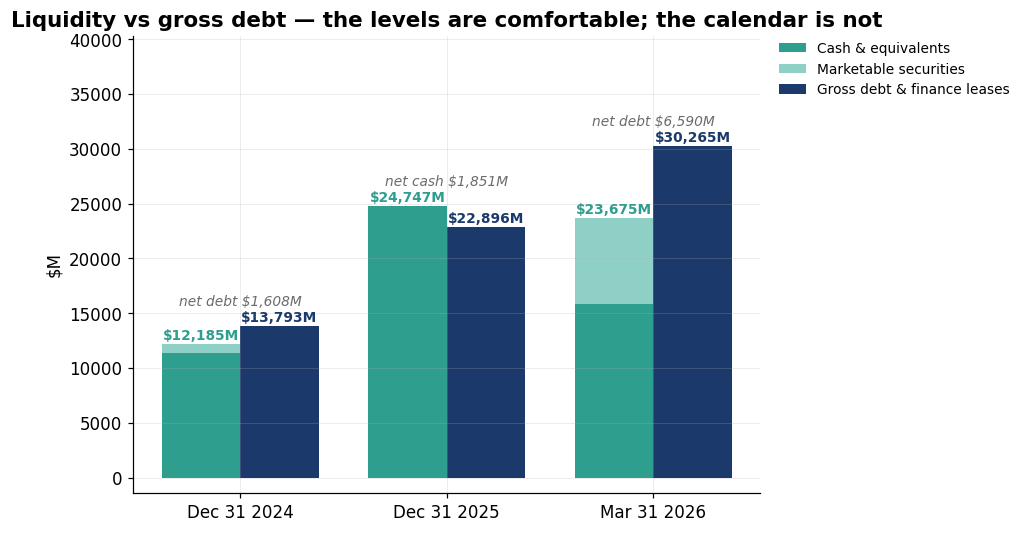

In [2]:
dates  = ["2024-12-31", "2025-12-31", "2026-03-31"]
labels = ["Dec 31 2024", "Dec 31 2025", "Mar 31 2026"]

liq = pd.DataFrame({
    "Cash & equivalents":  [bsv("Cash and cash equivalents", x) for x in dates],
    "Marketable securities": [bsv("Marketable securities", x) for x in dates],
    "Gross debt & leases": [dsv("Total debt and finance leases", x) for x in dates],
}, index=labels)
liq["Total liquidity"] = liq["Cash & equivalents"] + liq["Marketable securities"]
liq["Net debt"]        = liq["Gross debt & leases"] - liq["Total liquidity"]
display(fmt(liq[["Cash & equivalents","Marketable securities","Total liquidity",
                 "Gross debt & leases","Net debt"]]))

fig, ax = plt.subplots(figsize=(9.2, 5))
x = np.arange(len(labels)); w = 0.38
ce, ms = liq["Cash & equivalents"].values, liq["Marketable securities"].values
gd = liq["Gross debt & leases"].values
ax.bar(x - w/2, ce, w, color=TEAL,  label="Cash & equivalents")
ax.bar(x - w/2, ms, w, bottom=ce, color=LTEAL, label="Marketable securities")
ax.bar(x + w/2, gd, w, color=NAVY,  label="Gross debt & finance leases")
for i in range(len(labels)):
    ax.text(x[i]-w/2, ce[i]+ms[i]+400, f"${ce[i]+ms[i]:,.0f}M", ha="center", fontsize=9, fontweight="bold", color=TEAL)
    ax.text(x[i]+w/2, gd[i]+400, f"${gd[i]:,.0f}M", ha="center", fontsize=9, fontweight="bold", color=NAVY)
    nd = liq["Net debt"].values[i]
    ndlbl = f"net cash ${-nd:,.0f}M" if nd < 0 else f"net debt ${nd:,.0f}M"
    ax.annotate(ndlbl, (x[i], max(ce[i]+ms[i], gd[i])+1900),
                ha="center", fontsize=9, color=GREY, style="italic")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("$M"); ax.set_ylim(0, 36000)
ax.set_title("Liquidity vs gross debt — the levels are comfortable; the calendar is not")
charts.legend_outside(ax, loc="upper left", fontsize=9)
charts.pad_ylim(ax)
charts.save(fig, "debt_liquidity_vs_debt"); plt.show()

Note the **\$13B swing in cash** between Dec 2024 and Dec 2025 (\$11.4B → \$24.7B): that's the
year SpaceX raised \$18.8B of equity and \$16.1B of debt to feed AI capex. Cash then *fell* \$8.9B in
a single quarter (to \$15.9B at Mar 31 2026) as \$16.7B of investing cash went out the door. **This is
not a company living off its own cash flows — it's a company intermediating capital-market inflows
into capex at high velocity.** The debt is one of the two taps (the other is equity), which is exactly
why the maturity of that debt matters so much.


## 2. The debt stack today (March 31, 2026)

After the March 2026 refinancing (§3), the stack is unusually *simple* for a company this size — four
real line items plus finance leases:

- **SpaceX Bridge Loan — \$20.0B.** Unsecured, parent-level, guaranteed by X Corp., X.AI LLC and CTC
  Property LLC. Floating: Term SOFR + 0.75%–1.75% depending on credit rating; **effective rate 4.58%**.
  Matures **Sep 2, 2027**, extendable twice (3 months each) to **March 2028**. This single instrument
  is **66% of all debt**.
- **X 2027 & X 2030 Notes — \$27M.** Vestigial. Twitter-era senior unsecured notes (3.875% due 2027,
  5.000% due 2030); ~97% were bought back in 2022. Rounding error, kept for completeness.
- **Other financings — \$9.1B.** Equipment financings (monthly principal + interest, ~5.5% avg) plus
  **~\$4.5B of AI-infrastructure "failed sale-leaseback" debt** — data-center assets CTC tried to sell
  and lease back, but the accounting kept them on balance sheet as debt. This bucket *doubled* from
  \$4.6B in Q4 as the AI buildout was financed.
- **Finance lease liability — \$1.2B.** Leased assets treated as owned-and-financed.

The table is the whole capital structure on the liability side.


,Principal,Secured?,Rate type,Stated rate,Effective %,Maturity
instrument,,,,,,
SpaceX Bridge Loan,"$20,000M",unsecured,floating,Term SOFR + 0.75%-1.75%,4.58%,2027-09-02
X 2027 Notes,$25M,unsecured,fixed,3.875%,nan%,2027-12-15
X 2030 Notes,$2M,unsecured,fixed,5.000%,nan%,2030-03-01
Other financings,"$9,105M",secured,fixed,~5.5% avg,nan%,various
Finance lease liability,"$1,154M",nan,nan,nan,nan%,various


Undrawn backup liquidity — SpaceX Credit Facility: $1,500M capacity (amended to $5,000M in May 2026), $0 drawn.
Total debt: $29,111M  |  + finance leases: $30,265M  |  short-term portion due <12mo: $1,538M


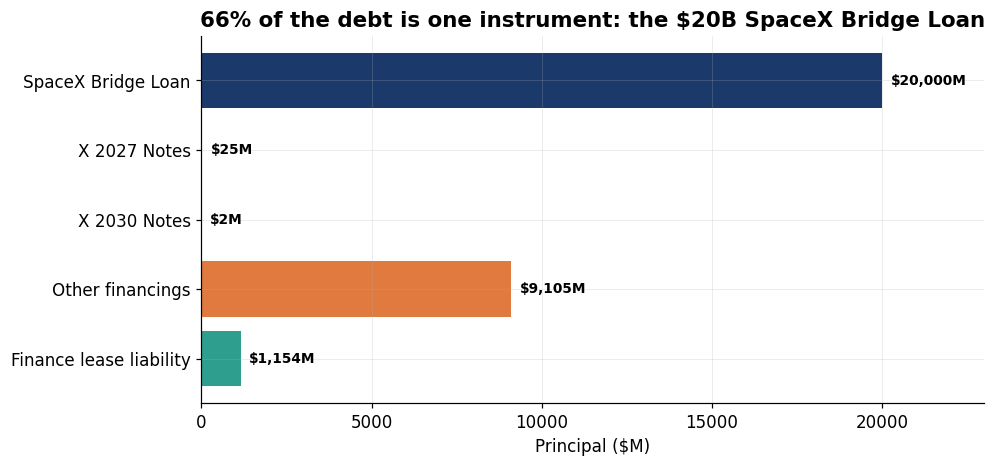

In [3]:
cur = terms[(terms.as_of_date == "2026-03-31") & (terms.status == "current")].copy()
order = ["SpaceX Bridge Loan", "X 2027 Notes", "X 2030 Notes", "Other financings", "Finance lease liability"]
cur["__o"] = cur.instrument.map({n:i for i,n in enumerate(order)})
cur = cur.sort_values("__o")
tbl = cur.set_index("instrument")[["principal","secured","rate_type","stated_rate","effective_rate_pct","maturity_date"]]
tbl = tbl.rename(columns={"principal":"Principal","secured":"Secured?","rate_type":"Rate type",
                          "stated_rate":"Stated rate","effective_rate_pct":"Effective %","maturity_date":"Maturity"})
display(fmt(tbl, rate=["Effective %"]))

# Plus the undrawn revolver and the headline totals
undrawn = terms[(terms.as_of_date=="2026-03-31") & (terms.status=="undrawn")]
print("Undrawn backup liquidity — SpaceX Credit Facility: $1,500M capacity (amended to $5,000M in May 2026), $0 drawn.")
print("Total debt: ${:,.0f}M  |  + finance leases: ${:,.0f}M  |  short-term portion due <12mo: ${:,.0f}M".format(
    dsv("Total debt","2026-03-31"),
    dsv("Total debt and finance leases","2026-03-31"),
    dsv("Less: Short-term portion","2026-03-31")))

# Horizontal bar: principal by instrument, Bridge dominating
fig, ax = plt.subplots(figsize=(9.2, 4.4))
names = list(tbl.index); prin = tbl["Principal"].values
cols  = [NAVY, GREY, GREY, ORANGE, TEAL]
y = np.arange(len(names))[::-1]
ax.barh(y, prin, color=cols)
for yi, p, nm in zip(y, prin, names):
    ax.text(p+250, yi, f"${p:,.0f}M", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(y); ax.set_yticklabels(names)
ax.set_xlabel("Principal ($M)"); ax.set_xlim(0, 23000)
ax.set_title("66% of the debt is one instrument: the $20B SpaceX Bridge Loan")
charts.finish(fig); charts.save(fig, "debt_stack_today", layout=False); plt.show()

## 3. The March 2026 refinancing — five expensive loans become one cheap bridge

The current stack is simple because, on **March 2, 2026**, SpaceX blew up the old one. Coming into
2026 the company (now including xAI, acquired Feb 2, 2026) carried **five high-rate, secured,
subsidiary-level loans** — the legacy of the Twitter LBO and xAI's debt-funded compute spree:

| Loan | Principal | Stated | Effective | Matured |
|---|--:|---|--:|---|
| X B-1 Term Loan | \$6,504M | SOFR + 6.50% | **12.40%** | Oct 2029 |
| X B-3 Term Loan | \$5,966M | 9.50% fixed | **9.80%** | Oct 2029 |
| xAI 12.5% Secured Senior Notes | \$3,000M | 12.50% fixed | **12.50%** | Jun 2030 |
| xAI Fixed Rate Term Loan | \$995M | 12.50% fixed | **11.91%** | Jun 2030 |
| xAI Floating Rate Term Loan | \$995M | SOFR + 7.25% | **12.48%** | Jun 2030 |

SpaceX raised a single **\$20B unsecured bridge loan at 4.58%** and used it to repay all five. The
trade is exactly what a newly-investment-grade-ish parent does to junk-rated subsidiaries: **lend them
your balance sheet.** The blended ~11.5% cost of the old stack collapses to 4.58% — and even though
SpaceX ended up with *more* principal (\$20.0B vs \$17.5B), the annual interest bill on that slice
**falls by roughly \$1.1B**.

There's no free lunch, though, and the S-1 books it explicitly: extinguishing the old loans (with
their prepayment penalties and unamortized fees) triggered a **\$1,526M loss on debt extinguishment**,
recorded in Other expense — the single biggest reason Q1-2026 swung to a **\$(4,276)M net loss**.
A real, one-time cash-and-paper cost to buy a much lower run-rate. The two charts: the rate collapse,
and the principal bridge.


Weighted avg effective rate, old stack: 11.51%  ->  Bridge Loan: 4.58%
Annual interest on refinanced slice: ~$2,009M (on $17,460M)  ->  ~$916M (on $20,000M)
Annual interest saved despite +$2,540M more principal: ~$1,093M


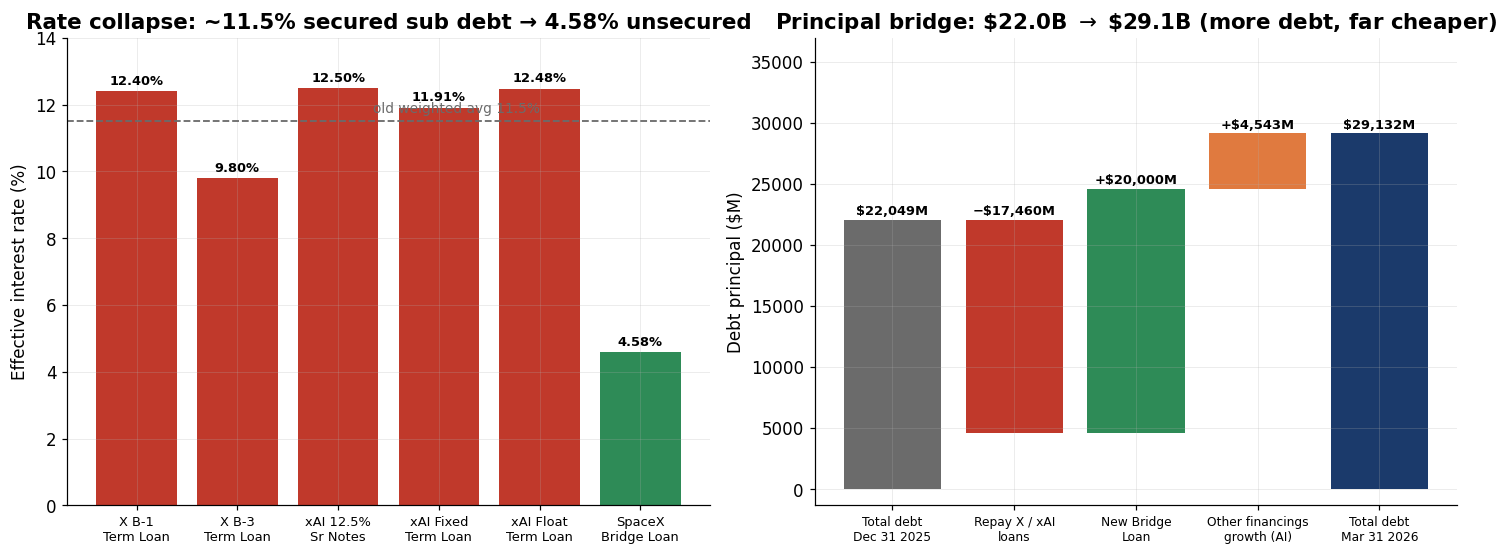

In [4]:
ext = terms[(terms.as_of_date=="2025-12-31") & (terms.status=="extinguished")].copy()
ext_order = ["X B-1 Term Loan","X B-3 Term Loan","xAI 12.5% Secured Senior Notes",
             "xAI Fixed Rate Term Loan","xAI Floating Rate Term Loan"]
ext["__o"] = ext.instrument.map({n:i for i,n in enumerate(ext_order)})
ext = ext.sort_values("__o")
w_old = float((ext.principal * ext.effective_rate_pct).sum() / ext.principal.sum())   # weighted avg eff rate
bridge_rate = float(terms[(terms.instrument=="SpaceX Bridge Loan")].effective_rate_pct.iloc[0])
old_int = float((ext.principal * ext.effective_rate_pct / 100).sum())
new_int = 20000 * bridge_rate/100
print(f"Weighted avg effective rate, old stack: {w_old:.2f}%  ->  Bridge Loan: {bridge_rate:.2f}%")
print(f"Annual interest on refinanced slice: ~${old_int:,.0f}M (on $17,460M)  ->  ~${new_int:,.0f}M (on $20,000M)")
print(f"Annual interest saved despite +$2,540M more principal: ~${old_int-new_int:,.0f}M")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# (a) effective-rate collapse
ax = axes[0]
names = list(ext.instrument) + ["SpaceX Bridge Loan"]
short_lbl = ["X B-1\nTerm Loan", "X B-3\nTerm Loan", "xAI 12.5%\nSr Notes",
             "xAI Fixed\nTerm Loan", "xAI Float\nTerm Loan", "SpaceX\nBridge Loan"]
rates = list(ext.effective_rate_pct) + [bridge_rate]
cols  = [RED]*len(ext) + [GREEN]
xb = np.arange(len(names))
ax.bar(xb, rates, color=cols)
ax.axhline(w_old, ls="--", color=GREY, lw=1.2)
ax.text(len(ext)-1, w_old+0.25, f"old weighted avg {w_old:.1f}%", ha="right", fontsize=9, color=GREY)
for xi, r in zip(xb, rates):
    ax.text(xi, r+0.2, f"{r:.2f}%", ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(xb); ax.set_xticklabels(short_lbl, fontsize=8.5)
ax.set_ylabel("Effective interest rate (%)"); ax.set_ylim(0, 14)
ax.set_title("Rate collapse: ~11.5% secured sub debt → 4.58% unsecured")

# (b) principal waterfall Dec25 -> Mar26 total debt
ax = axes[1]
start = dsv("Total debt","2025-12-31", "principal")
ext_sum = float(ext.principal.sum())
other_chg = dsv("Other financings","2026-03-31","principal") - dsv("Other financings","2025-12-31","principal")
end = dsv("Total debt","2026-03-31","principal")
steps = [("Total debt\nDec 31 2025", start, GREY, "abs"),
         ("Repay X / xAI\nloans", -ext_sum, RED, "rel"),
         ("New Bridge\nLoan", +20000, GREEN, "rel"),
         ("Other financings\ngrowth (AI)", +other_chg, ORANGE, "rel"),
         ("Total debt\nMar 31 2026", end, NAVY, "abs")]
xb = np.arange(len(steps)); base = 0.0
for i,(lab,val,c,kind) in enumerate(steps):
    if kind == "abs":
        ax.bar(xb[i], val, color=c); base = val
        ax.text(xb[i], val+400, f"${val:,.0f}M", ha="center", fontsize=8.5, fontweight="bold")
    else:
        bottom = base if val >= 0 else base+val
        ax.bar(xb[i], abs(val), bottom=bottom, color=c)
        ax.text(xb[i], bottom+abs(val)+400, f"{'+' if val>=0 else '−'}${abs(val):,.0f}M",
                ha="center", fontsize=8.5, fontweight="bold")
        base += val
ax.set_xticks(xb); ax.set_xticklabels([s[0] for s in steps], fontsize=8)
ax.set_ylabel("Debt principal ($M)"); ax.set_ylim(0, 33000)
ax.set_title(r"Principal bridge: \$22.0B $\rightarrow$ \$29.1B (more debt, far cheaper)")
plt.tight_layout(); charts.pad_ylim(ax)
charts.save(fig, "debt_refinancing"); plt.show()

## 4. The cash cost of debt — what they actually pay

Three different "interest" numbers appear in the filing; keep them straight:

- **Interest expense (income statement)** — the accrued P&L charge. **\$1,945M in FY2025**, rising as
  the AI debt stacked up; \$664M in Q1-2026 alone (which still contained the *old* expensive loans for
  most of the quarter).
- **Interest expense before capitalization** — \$1,797M FY2025. The difference (\$169M) is **capitalized
  interest**: borrowing cost rolled into the cost of assets under construction (data centers, launch
  pads) instead of hitting the P&L. A capex-heavy company gets to defer some interest onto the balance
  sheet this way.
- **Cash paid for interest** — **\$1,476M FY2025**. The actual cash out the door.

Set against interest *income* of \$492M (FY2025) on all that cash and securities, the **net** interest
drag is smaller than the gross number suggests. The chart shows the trend; then we build the
**post-refinancing run-rate**, which is the number that matters going forward.

**What "run rate" means — and why it matters here.** The reported interest figures above all look
*backward*: FY2025's \$1,945M and Q1-2026's \$664M both reflect the *old* ~11.5% loans that no longer
exist. To see the *go-forward* cost you build a **run rate** — annualize today's actual stack at today's
rates, as if the current terms simply persist for a full year. Post-refinancing that's roughly
**\$1.5B/yr** (the \$20B bridge at 4.58% plus the small remainder), against a Q1-2026 *pace* of ~\$2.7B
annualized. So the refinancing didn't just trim a line item; it **reset the company's forward interest
base by ~\$1B a year.** That run-rate — not the trailing P&L — is the interest number to carry into any
forecast of cash needs (§7).


,Interest expense,Interest income,Net interest expense,Cash paid for interest
FY2023,"$1,693M",$249M,"$1,444M","$1,365M"
FY2024,"$1,580M",$371M,"$1,209M","$1,500M"
FY2025,"$1,945M",$492M,"$1,453M","$1,476M"


Illustrative POST-refinancing annual interest run-rate (assumptions in labels):
   Bridge Loan (20,000 @ 4.58%)           ~$916M
   Other financings (9,105 @ ~5.5%)       ~$501M
   Finance leases (~1,154 @ ~5%)          ~$58M
   TOTAL run-rate                         ~$1,474M  (vs $1,945M FY2025 accrued, and a Q1-2026 pace of ~$2,656M)


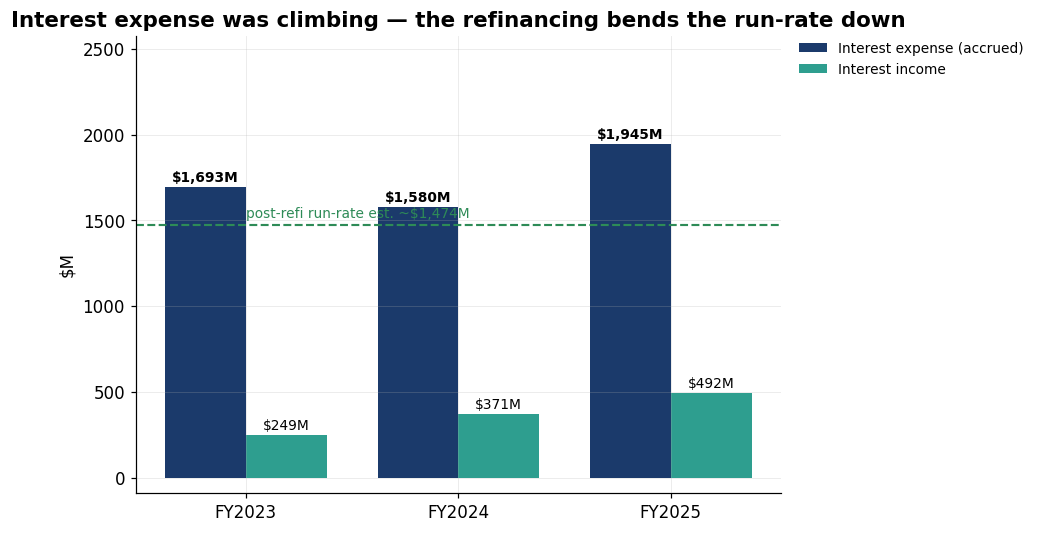

In [5]:
periods = ["FY2023","FY2024","FY2025"]
cost = pd.DataFrame({
    "Interest expense":        [-isv("Interest expense", p) for p in periods],
    "Interest income":         [ isv("Interest income", p) for p in periods],
    "Cash paid for interest":  [ cfv("Cash paid for interest net of interest capitalized", p) for p in periods],
}, index=periods)
cost["Net interest expense"] = cost["Interest expense"] - cost["Interest income"]
display(fmt(cost[["Interest expense","Interest income","Net interest expense","Cash paid for interest"]]))

# Post-refinance annual run-rate estimate (explicit assumptions)
rr = {
    "Bridge Loan (20,000 @ 4.58%)":      20000 * 4.58/100,
    "Other financings (9,105 @ ~5.5%)":  9105 * 5.5/100,
    "Finance leases (~1,154 @ ~5%)":     1154 * 5.0/100,
}
rr_total = sum(rr.values())
print("Illustrative POST-refinancing annual interest run-rate (assumptions in labels):")
for k,v in rr.items(): print(f"   {k:38s} ~${v:,.0f}M")
print(f"   {'TOTAL run-rate':38s} ~${rr_total:,.0f}M  (vs $1,945M FY2025 accrued, and a Q1-2026 pace of ~$2,656M)")

fig, ax = plt.subplots(figsize=(9.2, 5))
x = np.arange(len(periods)); w = 0.38
ie = cost["Interest expense"].values; ii = cost["Interest income"].values
ax.bar(x - w/2, ie, w, color=NAVY, label="Interest expense (accrued)")
ax.bar(x + w/2, ii, w, color=TEAL, label="Interest income")
for i in range(len(periods)):
    ax.text(x[i]-w/2, ie[i]+30, f"${ie[i]:,.0f}M", ha="center", fontsize=9, fontweight="bold")
    ax.text(x[i]+w/2, ii[i]+30, f"${ii[i]:,.0f}M", ha="center", fontsize=9)
ax.axhline(rr_total, ls="--", color=GREEN, lw=1.4)
ax.text(0, rr_total+40, f"post-refi run-rate est. ~${rr_total:,.0f}M", fontsize=9, color=GREEN)
ax.set_xticks(x); ax.set_xticklabels(periods)
ax.set_ylabel("$M"); ax.set_ylim(0, 2300)
ax.set_title("Interest expense was climbing — the refinancing bends the run-rate down")
charts.legend_outside(ax, loc="upper left", fontsize=9)
charts.pad_ylim(ax)
charts.save(fig, "debt_cost_of_debt"); plt.show()

**Rate sensitivity.** The S-1 spells it out: a **100bp rise in rates adds ~\$200M of annual
interest expense.** That's almost exactly 1% of the \$20B Bridge Loan — confirming that the company's
rate risk *is* the bridge (everything else is fixed or trivial). Today, floating exposure at 4.58% is
cheap; if the bridge is still outstanding into a higher-rate 2027, that \$200M-per-100bp lever cuts the
wrong way. Another reason to want it gone (§5, §7).


## 5. The maturity wall — when the principal actually comes due

This is the crux. The refinancing made the debt **cheaper** but **shorter**, and a creditor cares at
least as much about *when* as *how much*.

**Left chart — the as-filed schedule (Dec 31 2025).** Before the refinancing, principal was termed
out nicely: almost nothing due until a **\$13.5B wall in 2029** and \$6.0B in 2030. Comfortable.

**Right chart — the reality after March 2026.** Those 2029–2030 maturities were the X/xAI loans that
got repaid. In their place sits the **\$20B Bridge Loan maturing September 2027** (extendable to March
2028). The wall didn't shrink — **it moved forward ~2 years and got concentrated into a single
bullet.** Roughly **\$21.5B comes due by 2027/2028** once you include the current portion.

That is the entire logic of the IPO timing. The Bridge Loan agreement *requires* SpaceX to apply the
net proceeds of a qualified IPO to repay it **within six months**. The bridge is, by construction, a
loan that assumes the equity raise happens.


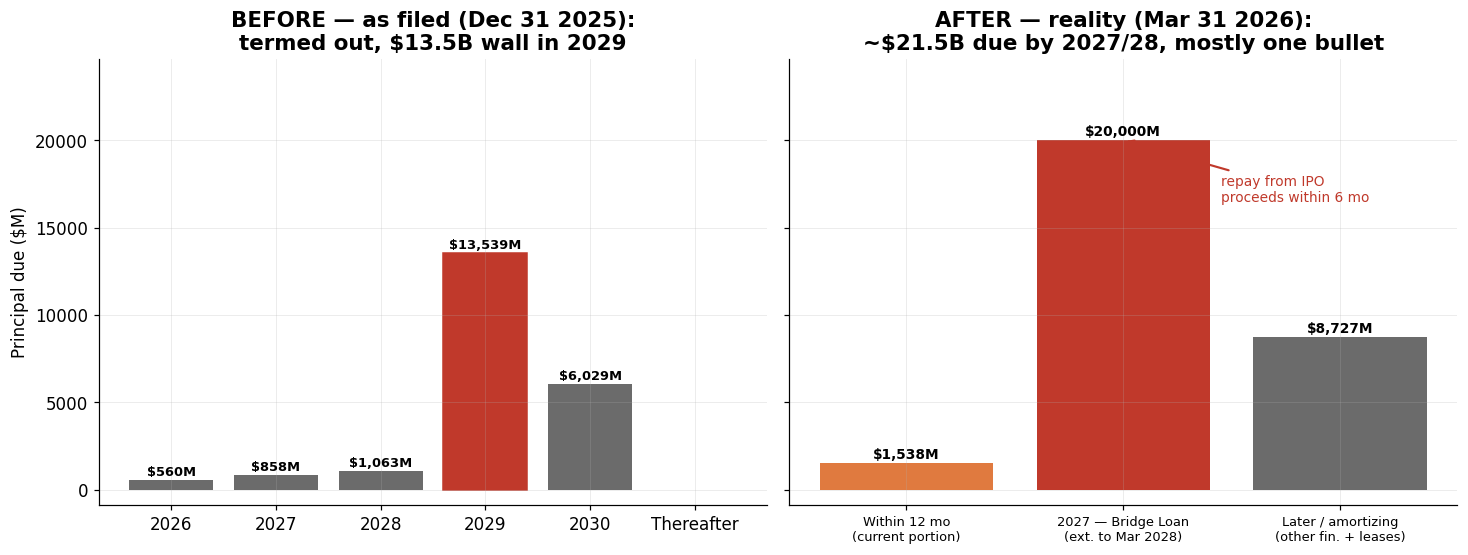

Note: the post-refinancing year-by-year split of 'other financings' is not separately disclosed
in the S-1; the right-hand chart buckets it as current vs longer-dated/amortizing. The $20B
Bridge bullet and the $1,538M current portion are exact.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharey=True)

# (a) as-filed Dec 31 2025 schedule
ax = axes[0]
m = mats.copy()
yrs = list(m.maturity_year.astype(str)); vals = list(m.principal)
xb = np.arange(len(yrs))
bars = ax.bar(xb, vals, color=GREY)
bars[3].set_color(RED)  # 2029 wall
for xi, v in zip(xb, vals):
    if v > 0: ax.text(xi, v+250, f"${v:,.0f}M", ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(xb); ax.set_xticklabels(yrs)
ax.set_ylabel("Principal due ($M)")
ax.set_title("BEFORE — as filed (Dec 31 2025):\ntermed out, $13.5B wall in 2029")

# (b) post-refinance reality (Mar 31 2026)
ax = axes[1]
short = dsv("Less: Short-term portion","2026-03-31")
total_dl = dsv("Total debt and finance leases","2026-03-31")
longer = total_dl - short - 20000
buckets = ["Within 12 mo\n(current portion)", "2027 — Bridge Loan\n(ext. to Mar 2028)",
           "Later / amortizing\n(other fin. + leases)"]
bvals = [short, 20000, longer]
bcols = [ORANGE, RED, GREY]
xb = np.arange(len(buckets))
ax.bar(xb, bvals, color=bcols)
for xi, v in zip(xb, bvals):
    ax.text(xi, v+250, f"${v:,.0f}M", ha="center", fontsize=9, fontweight="bold")
ax.annotate("repay from IPO\nproceeds within 6 mo",
            xy=(1, 20000), xytext=(1.45, 16500), fontsize=9, color=RED, ha="left",
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.4))
ax.set_xticks(xb); ax.set_xticklabels(buckets, fontsize=8.5)
ax.set_title("AFTER — reality (Mar 31 2026):\n~$21.5B due by 2027/28, mostly one bullet")
ax.set_ylim(0, 22000)
plt.tight_layout(); charts.pad_ylim(ax)
charts.save(fig, "debt_maturity_wall"); plt.show()
print("Note: the post-refinancing year-by-year split of 'other financings' is not separately disclosed")
print("in the S-1; the right-hand chart buckets it as current vs longer-dated/amortizing. The $20B")
print("Bridge bullet and the $1,538M current portion are exact.")

## 6. Net debt & the leverage covenant — how much rope is left

The Bridge Loan carries **one financial maintenance covenant** (plus the usual negative covenants —
no disposing of Starlink, limits on liens and subsidiary debt). It's a **Consolidated Leverage Ratio**:

$$\text{Leverage} = \frac{\text{funded debt} - 85\%\times\text{unrestricted cash}}{\text{Consolidated EBITDA}} \le 3.75\times$$

(with a temporary step-up to 4.25× for four quarters after a \$1B+ acquisition). Plain English:
**net debt can't exceed 3.75 years of earnings.** Breach it and the \$20B can be called — the corporate
equivalent of a margin call. The S-1 confirms SpaceX was **in compliance at Mar 31 2026**.

We can't reproduce "Consolidated EBITDA (as defined)" exactly — it has lender-negotiated add-backs we
don't see — so we approximate it with reported **FY2025 Adjusted EBITDA (\$6.6B)** and flag it as an
estimate. Even on that conservative proxy there's real headroom; the covenant is not the near-term
binding constraint. (The *maturity*, not the *ratio*, is what forces the IPO.)

> **Why equity investors should largely ignore EBITDA here.** EBITDA strips out depreciation and
> amortization; *Adjusted* EBITDA also adds back stock-based comp and one-offs. For most companies those
> are non-cash "noise." For SpaceX they are **the business itself**: the entire model is to pour
> \$20B+/yr into satellites, rockets, and data centers that then *depreciate*, and to pay much of its
> talent in *stock*. Add those back and you're measuring the earnings of a company that buys no
> satellites and pays no engineers — i.e., not SpaceX. EBITDA earns its keep for *this one purpose*: it
> is the basis the lenders' covenant is written on, because they get repaid *before* the company
> reinvests. For valuing the **equity**, ignore both Adjusted *and* GAAP EBITDA and judge what's left
> after the capital and comp that actually run the business — **free cash flow** (§7), and ultimately
> GAAP earnings. The ~1.0x leverage that reassures a lender tells an equity owner almost nothing about
> whether this company makes money.


,Value
Funded debt & leases,"$30,265M"
Cash & equivalents,"$15,852M"
Marketable securities,"$7,823M"
Covenant net debt (−85% cash),"$16,791M"
'True' net debt (−cash −securities),"$6,590M"
FY2025 Adjusted EBITDA (proxy),"$6,584M"


Covenant leverage (proxy):  2.55x   vs limit 3.75x   ->  headroom 1.20 turns
'True' net-debt / EBITDA:   1.00x


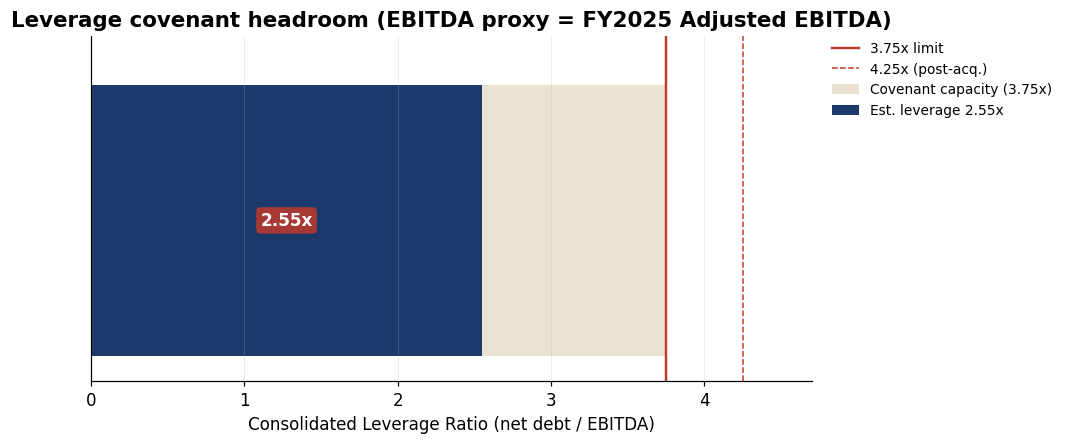

In [7]:
adj_ebitda_fy25 = float(coneb[(coneb.line_item=="Adjusted EBITDA") & (coneb.period=="FY2025")].value.iloc[0])
cash_mar = bsv("Cash and cash equivalents","2026-03-31")
sec_mar  = bsv("Marketable securities","2026-03-31")
funded   = dsv("Total debt and finance leases","2026-03-31")   # proxy for funded indebtedness

cov_net   = funded - 0.85*cash_mar                 # covenant definition (85% of unrestricted cash)
cov_ratio = cov_net / adj_ebitda_fy25
simple_net = funded - cash_mar - sec_mar           # 'true' net debt incl. securities
simple_ratio = simple_net / adj_ebitda_fy25

summary = pd.DataFrame({
    "Value": [funded, cash_mar, sec_mar, cov_net, simple_net, adj_ebitda_fy25]},
    index=["Funded debt & leases","Cash & equivalents","Marketable securities",
           "Covenant net debt (−85% cash)","'True' net debt (−cash −securities)","FY2025 Adjusted EBITDA (proxy)"])
display(fmt(summary))
print(f"Covenant leverage (proxy):  {cov_ratio:.2f}x   vs limit 3.75x   ->  headroom {3.75-cov_ratio:.2f} turns")
print(f"'True' net-debt / EBITDA:   {simple_ratio:.2f}x")

fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.barh([1], [3.75], color="#e9e2d0", label="Covenant capacity (3.75x)")
ax.barh([1], [cov_ratio], color=NAVY, label=f"Est. leverage {cov_ratio:.2f}x")
ax.axvline(3.75, color=RED, lw=1.6, label="3.75x limit")
ax.axvline(4.25, color=RED, lw=1.0, ls="--", label="4.25x (post-acq.)")
ax.text(cov_ratio/2, 1, f"{cov_ratio:.2f}x", va="center", ha="center", color="white", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.25", facecolor=RED, alpha=0.85, edgecolor="none"))
ax.set_xlim(0, 4.7); ax.set_yticks([]); ax.set_xlabel("Consolidated Leverage Ratio (net debt / EBITDA)")
ax.set_title("Leverage covenant headroom (EBITDA proxy = FY2025 Adjusted EBITDA)")
charts.legend_outside(ax, loc="upper left", fontsize=9)
charts.finish(fig); charts.pad_ylim(ax)
charts.save(fig, "debt_covenant_headroom", layout=False); plt.show()

## 7. Solvency & the raise — how much, how dilutive, and what ends the cycle

Now connect debt to the IPO. Two facts set the size of the ask:

1. **The \$20B Bridge must be repaid from IPO proceeds within six months.** That's not optional; it's
   contractual. So the IPO has to clear ~\$20B *just to retire the bridge* before funding anything.
2. **The business burns cash.** Free cash flow = operating cash − capex. SpaceX generates strong and
   growing **operating** cash (\$6.8B FY2025), but capex (\$20.7B FY2025) is ~3× larger — so **FCF was
   about −\$14B in FY2025**, and the Q1-2026 pace is worse. That gap is filled by issuing equity and
   debt. Until it closes, *every year needs a fresh injection of capital.*

So the IPO is doing two jobs at once: **refinance the bridge** *and* **pre-fund the capex gap.** The
chart below sizes both. The uncomfortable arithmetic for shareholders: money raised as **equity
dilutes** existing owners; money raised (or rolled) as **debt** reloads the interest bill and the next
maturity wall. The only lever that shrinks *both* over time is **free cash flow** — and that means the
**Connectivity (Starlink) profit engine** growing fast enough to fund Space and AI internally.

**This is a recurring need, not a one-off.** The bridge takeout is a single \$20B event; the capex gap
is *structural*. As long as SpaceX invests far more than it earns in cash, **every year demands a fresh
injection** — debt, equity, or both. The job of *this* notebook is only to **size the need and its hard
constraints**: the \$20B repayment obligation, the ~\$14B/yr FCF gap, and the rate- and covenant-limits
around them. It deliberately stops short of **projecting** the future raises, the debt-vs-equity mix, or
the resulting dilution and share count — that forecasting lives in the integrated model and report,
which take these figures as inputs. What we hand forward is the *shape* of the requirement: a large
near-term takeout sitting on top of a recurring annual funding gap, with growth in cash generation the
only thing that shrinks it.


,Operating cash flow,Capex,Free cash flow
period,,,
FY2023,"$4,520M","$4,415M",$105M
FY2024,"$5,776M","$11,163M","$-5,387M"
FY2025,"$6,785M","$20,737M","$-13,952M"


FY2025 Segment Adjusted EBITDA — Connectivity carries the company:
   Space          $653M
   Connectivity   $7,168M
   AI             $-1,237M


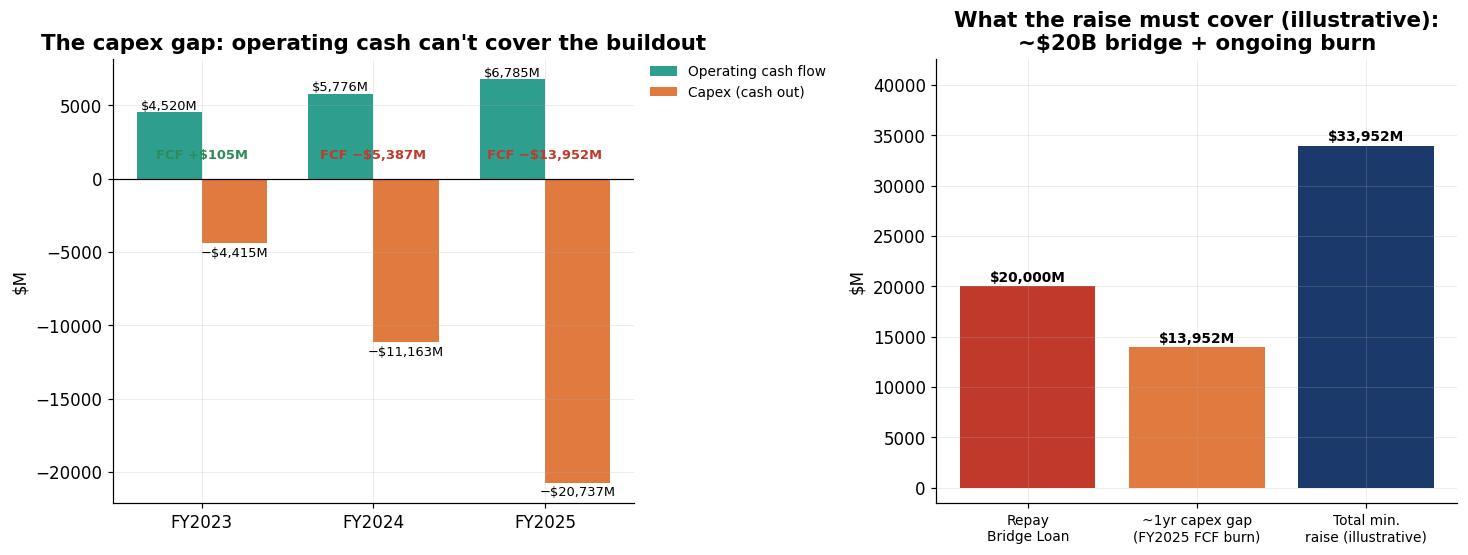


Illustrative only — not S-1 guidance. Actual IPO size, future FCF, and the equity/debt mix
determine the dilution. The point: the raise is anchored by a hard $20B repayment obligation
on top of a structurally cash-hungry capex plan.


In [8]:
# Free cash flow history (operating cash - PP&E capex)
fcf_rows = []
for p in ["FY2023","FY2024","FY2025"]:
    ocf  = cfv("Net cash provided by operating activities", p)
    capx = -cfv("Purchases of property plant and equipment", p)
    fcf_rows.append((p, ocf, capx, ocf-capx))
fcf = pd.DataFrame(fcf_rows, columns=["period","Operating cash flow","Capex","Free cash flow"]).set_index("period")
display(fmt(fcf))

# Segment Adjusted EBITDA FY2025 — who actually generates the cash
seg = segeb[(segeb.line_item=="Segment Adjusted EBITDA") & (segeb.period=="FY2025")]
seg = seg.set_index("segment")["value"].reindex(["Space","Connectivity","AI"])
print("FY2025 Segment Adjusted EBITDA — Connectivity carries the company:")
for s in seg.index: print(f"   {s:14s} ${seg[s]:,.0f}M")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# (a) the cash gap the IPO must pre-fund
ax = axes[0]
p = list(fcf.index); x = np.arange(len(p)); w = 0.38
ocf = fcf["Operating cash flow"].values; cap = fcf["Capex"].values
ax.bar(x - w/2, ocf, w, color=TEAL, label="Operating cash flow")
ax.bar(x + w/2, -cap, w, color=ORANGE, label="Capex (cash out)")
for i in range(len(p)):
    ax.text(x[i]-w/2, ocf[i]+200, f"${ocf[i]:,.0f}M", ha="center", fontsize=8.5)
    ax.text(x[i]+w/2, -cap[i]-900, f"−${cap[i]:,.0f}M", ha="center", fontsize=8.5)
    fcf_i = ocf[i] - cap[i]                       # FY2023 is actually +$105M; sign it correctly
    sign  = "−" if fcf_i < 0 else "+"
    ax.text(x[i], 1400, f"FCF {sign}${abs(fcf_i):,.0f}M", ha="center", fontsize=8.5,
            color=(RED if fcf_i < 0 else GREEN), fontweight="bold")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(p); ax.set_ylabel("$M")
ax.set_title("The capex gap: operating cash can't cover the buildout")
charts.legend_outside(ax, loc="upper left", fontsize=9)# (b) illustrative IPO 'uses' — bridge + a year of cash burn
ax = axes[1]
fcf25 = ocf[-1] - cap[-1]                  # negative
uses = ["Repay\nBridge Loan", "~1yr capex gap\n(FY2025 FCF burn)", "Total min.\nraise (illustrative)"]
uvals = [20000, -fcf25, 20000 - fcf25]
ucols = [RED, ORANGE, NAVY]
xb = np.arange(len(uses))
ax.bar(xb, uvals, color=ucols)
for xi, v in zip(xb, uvals):
    ax.text(xi, v+500, f"${v:,.0f}M", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(xb); ax.set_xticklabels(uses, fontsize=9)
ax.set_ylabel("$M"); ax.set_ylim(0, 38000)
ax.set_title("What the raise must cover (illustrative):\n~$20B bridge + ongoing burn")
plt.tight_layout(); charts.pad_ylim(ax)
charts.save(fig, "debt_solvency_raise"); plt.show()
print()
print("Illustrative only — not S-1 guidance. Actual IPO size, future FCF, and the equity/debt mix")
print("determine the dilution. The point: the raise is anchored by a hard $20B repayment obligation")
print("on top of a structurally cash-hungry capex plan.")

## What the debt picture tells you

- **The level of debt is fine; the structure is the story.** \$30B gross / ~\$6.6B net is
  ~1.0x by the lender's EBITDA math — investment-grade-ish (though EBITDA flatters a business that *is*
  capex and stock comp; for equity, read FCF, not EBITDA — §6). The risk isn't insolvency from
  leverage; it's the **concentration and timing** of one \$20B bullet.
- **The March 2026 refinancing was smart treasury, not deleveraging.** It cut the blended rate from
  ~11.5% to 4.58% (≈ \$1.1B/yr of interest saved) and simplified the stack — but it pulled the
  maturity wall forward from 2029–30 into a single **September 2027** bullet and cost a **\$1.5B**
  extinguishment loss. SpaceX traded *duration* for *cost* and bet the IPO closes first.
- **The IPO is, mechanically, a bridge-loan takeout.** The loan agreement requires repayment from IPO
  proceeds within six months. The first ~\$20B raised doesn't fund Mars or H100s — it pays back banks.
- **Debt isn't the funding model; capital markets are.** With ~−\$14B FCF, SpaceX needs continuous
  external capital. Every raise is a choice between **dilution** (equity) and **reloading the wall**
  (debt). The only exit is **FCF**, and the only near-term source of FCF is **Connectivity/Starlink** —
  which must keep compounding fast enough to bankroll Space and the AI capex furnace.
- **What this notebook sets up (and hands off).** A *recurring annual capital requirement*: roughly a
  \$20B near-term takeout on top of a ~\$14B/yr FCF gap. We **size** that need and its constraints here;
  we do **not** forecast how it's met. The debt-vs-equity mix, the dilution and share count, and the
  path to FCF breakeven are the next deliverables — they consume these numbers.
- **Watch in future filings:** (1) the post-IPO bridge balance — is it actually retired? (2) the
  floating-rate exposure into 2027 (the \$200M-per-100bp lever); (3) whether the AI "other financings"
  bucket keeps growing; (4) the leverage ratio as EBITDA and net debt both move.

> Bottom line: SpaceX's debt is cheap, lightly levered, and almost entirely **due before the end of
> 2027**. The S-1 isn't a fundraising nicety — it's the scheduled repayment event for a \$20B loan
> that was written assuming this exact IPO would happen.
